### Fake News Detection using Machine Learning Algorithms

**Objective:** Build a machine learning system that classifies news articles as fake or real.

**Dataset (Kaggle):** https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset



## Dataset Description

The dataset contains two CSV files: `Fake.csv` and `True.csv`. Each file includes news articles with fields like title, text, subject, and date.
We label fake news as `0` and real news as `1`.

In [ ]:
import re
import string
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## Data Loading

The code below loads the dataset from the local folder `News _dataset`. If the files are not found, download them from the Kaggle link above and place them in that folder.

In [ ]:
dataset_dir = Path("News _dataset")
fake_path = dataset_dir / "Fake.csv"
true_path = dataset_dir / "True.csv"

if not fake_path.exists() or not true_path.exists():
    raise FileNotFoundError(
        "Dataset files not found. Please download them from "
        "https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset "
        "and place Fake.csv and True.csv inside the 'News _dataset' folder."
    )

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

fake_df["label"] = 0
true_df["label"] = 1

news_df = pd.concat([fake_df, true_df], ignore_index=True)
news_df.head()

## Data Exploration

We check the dataset size, column names, class balance, and a quick look at text length distribution.

Dataset shape: (44898, 5)
Columns: ['title', 'text', 'subject', 'date', 'label']


label
Fake     23481
Real     21417
Name: count, dtype: int64

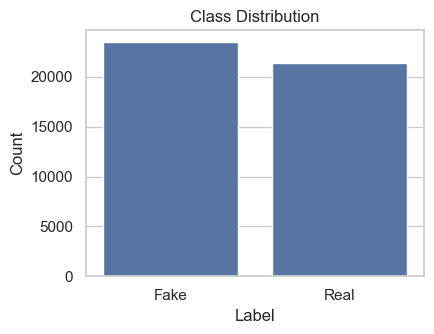

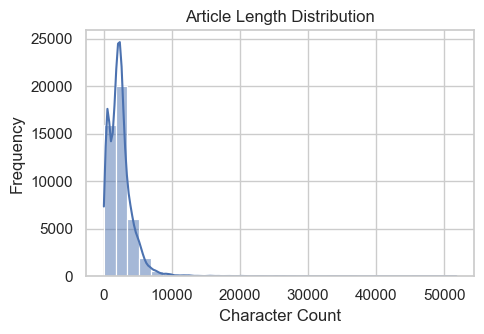

In [ ]:
print("Dataset shape:", news_df.shape)
print("Columns:", list(news_df.columns))
display(news_df[["label"]].value_counts().rename(index={0: "Fake", 1: "Real"}))

plt.figure(figsize=(4.5, 3.5))
sns.countplot(data=news_df, x="label")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ["Fake", "Real"])
plt.tight_layout()
plt.show()

lengths = news_df["text"].astype(str).str.len() if "text" in news_df.columns else news_df.iloc[:, 0].astype(str).str.len()
plt.figure(figsize=(5, 3.5))
sns.histplot(lengths, bins=30, kde=True)
plt.title("Article Length Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Data Cleaning and Preprocessing

We combine title and text if both exist, remove missing values, and keep only the content and label columns.

In [ ]:
news_df.columns = news_df.columns.str.strip()

if {"title", "text"}.issubset(news_df.columns):
    news_df["content"] = news_df["title"].fillna("") + " " + news_df["text"].fillna("")
elif "text" in news_df.columns:
    news_df["content"] = news_df["text"].fillna("")
elif "title" in news_df.columns:
    news_df["content"] = news_df["title"].fillna("")
else:
    raise ValueError("No suitable text column was found. Expected columns like 'title' or 'text'.")

news_df = news_df[["content", "label"]].dropna().reset_index(drop=True)
news_df = news_df[news_df["content"].str.strip() != ""].reset_index(drop=True)

print("Cleaned dataset shape:", news_df.shape)
news_df.head()

Cleaned dataset shape: (44898, 2)


,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,0


## Text Preprocessing

Steps:
- Lowercasing
- Removing punctuation and digits
- Tokenization
- Removing stopwords
- Rejoining tokens to cleaned text

In [ ]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)

news_df["clean_text"] = news_df["content"].apply(preprocess_text)

display(Markdown("**Before and after sample:**"))
sample = news_df.loc[:2, ["content", "clean_text"]].copy()
display(sample)

**Before and after sample:**

,content,clean_text
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends embarrassing new year’s eve...
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke internet joke threatening...


## Train-Test Split and TF-IDF Feature Extraction

We split the data and convert text to numerical features using TF-IDF.

**Note:** A stratified split preserves class balance in both training and test sets. For this dataset size, it provides a reliable baseline while avoiding the extra cost of k-fold validation.

In [ ]:
X = news_df["clean_text"]
y = news_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape

((35918, 5000), (8980, 5000))

## Model Training and Evaluation

We train each model on the same TF-IDF features and evaluate using accuracy, precision, recall, F1-score, the full classification report, and a confusion matrix.

In [ ]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1-score": f1_score(y_eval, y_pred, zero_division=0),
    }

    print(f"{name} - Classification Report")
    report = classification_report(y_eval, y_pred, output_dict=True, zero_division=0)
    display(pd.DataFrame(report).transpose().round(4))

    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
    plt.figure(figsize=(4.5, 3.5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"],
    )
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    return metrics

results = []

### Naive Bayes

Naive Bayes is a probabilistic classifier that assumes feature independence, which works well for word-based features.
It is fast, scalable, and often provides strong baselines for text classification with TF-IDF features.

Naive Bayes - Classification Report


,precision,recall,f1-score,support
0,0.9521,0.9438,0.9479,4696.0000
1,0.9390,0.9479,0.9434,4284.0000
accuracy,0.9458,0.9458,0.9458,0.9458
macro avg,0.9455,0.9459,0.9457,8980.0000
weighted avg,0.9458,0.9458,0.9458,8980.0000


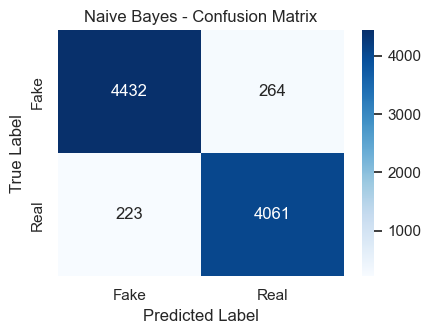

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_metrics = evaluate_model("Naive Bayes", nb_model, X_test_tfidf, y_test)
results.append(nb_metrics)

### Support Vector Machine (SVM)

SVM finds a decision boundary (hyperplane) that maximizes the margin between classes.
A linear kernel is effective for sparse, high-dimensional TF-IDF features and often performs strongly in text classification tasks.

In [ ]:
svm_model = SVC(kernel="linear", random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_metrics = evaluate_model("Support Vector Machine (SVM)", svm_model, X_test_tfidf, y_test)
results.append(svm_metrics)

### Random Forest

Random Forest builds an ensemble of decision trees and aggregates their predictions for robust performance.
It can capture non-linear patterns and works well with high-dimensional TF-IDF features, while reducing overfitting compared to a single tree.

Random Forest - Classification Report


,precision,recall,f1-score,support
0,0.9981,0.9985,0.9983,4696.0000
1,0.9984,0.9979,0.9981,4284.0000
accuracy,0.9982,0.9982,0.9982,0.9982
macro avg,0.9982,0.9982,0.9982,8980.0000
weighted avg,0.9982,0.9982,0.9982,8980.0000


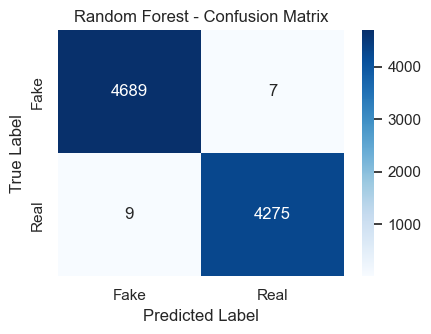

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
rf_metrics = evaluate_model("Random Forest", rf_model, X_test_tfidf, y_test)
results.append(rf_metrics)

## Performance Comparison

We summarize all metrics in a table and compare them in a bar chart.

,Accuracy,Precision,Recall,F1-score
Model,,,,
Naive Bayes,0.9458,0.9390,0.9479,0.9434
Support Vector Machine (SVM),0.9955,0.9942,0.9965,0.9953
Random Forest,0.9982,0.9984,0.9979,0.9981


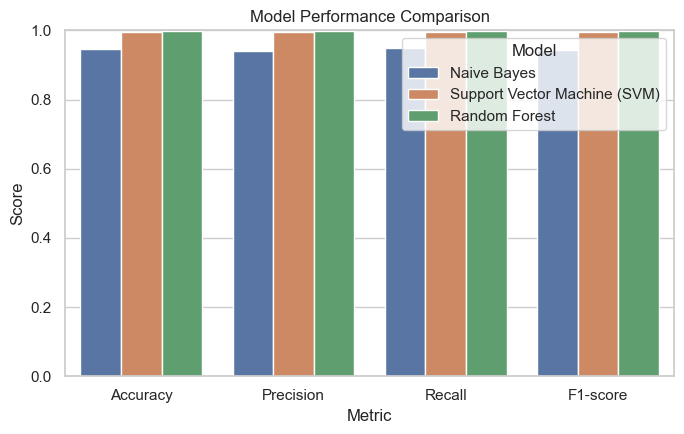

In [ ]:
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.apply(pd.to_numeric, errors="coerce").round(4)
display(results_df)

metrics_long = results_df.reset_index().melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=metrics_long, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Conclusion

We identify the best model using F1-score, which balances precision and recall. This is important when class imbalance exists and missing fake news (false negatives) can be costly.

In [ ]:
metric_name = "F1-score"
metric_series = results_df[metric_name].dropna()

if metric_series.empty:
    display(Markdown("**Best model:** Not available because metrics are missing."))
else:
    best_model = metric_series.idxmax()
    best_value = metric_series.loc[best_model]
    display(Markdown(
        f"**Best model:** {best_model} with {metric_name} = {best_value:.4f}. "
        "F1-score balances precision and recall, which is critical when fake news may be less frequent "
        "and false negatives are costly.",
    ))

**Best model:** Random Forest with F1-score = 0.9981. F1-score balances precision and recall, which is critical when fake news may be less frequent and false negatives are costly.